In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bioframe

In [38]:
def count_concordant_and_discordant_links(links):
    links['score'] = links['log2FoldChange_peak']*links['log2FoldChange_gene']
    counts_concordant, counts_discordant = [], []
    distances = [0, 5000, 10000, 25000, 50000, 100000, 250000, 500000, 1000000]
    for i in range(0, len(distances)-1):
        count_c = len(links[(links['distance'] >= distances[i]) & (links['distance'] < distances[i+1]) & (links['score'] > 0)])
        count_d = len(links[(links['distance'] >= distances[i]) & (links['distance'] < distances[i+1]) & (links['score'] < 0)])
        counts_concordant.append(count_c)
        counts_discordant.append(count_d)
    return([counts_concordant, counts_discordant])

def get_tss_positions(links):
    tss_starts, tss_ends = [], []
    for gene in links[['chrom_gene', 'start_gene', 'end_gene', 'strand_gene']].values:
        if gene[-1] == '+':
            tss_start = gene[1]-2500
            tss_end = gene[1]+2500
        else:
            tss_start = gene[2]-2500
            tss_end = gene[2]+2500
        tss_starts.append(tss_start)
        tss_ends.append(tss_end)
    links['start_tss_gene'] = tss_starts
    links['end_tss_gene'] = tss_ends
    return(links)

def overlap_links_and_tads(links, tads):
    links = get_tss_positions(links)
    
    overlap_links_tads_peaks = bioframe.overlap(links, tads, 
                                                cols1 = ['chrom_peak', 'start_peak', 'end_peak'], 
                                                cols2 = ['chrom_tad', 'start_tad', 'end_tad'],
                                                suffixes = ['', '_peak'], return_overlap = True)
    overlap_links_tads_genes = bioframe.overlap(overlap_links_tads_peaks, tads, 
                                                cols1 = ['chrom_gene', 'start_gene', 'end_gene'], 
                                                cols2 = ['chrom_tad', 'start_tad', 'end_tad'],
                                                suffixes = ['', '_gene'], return_overlap = True)
    overlap_links_tads = bioframe.overlap(overlap_links_tads_genes, tads, 
                                          cols1 = ['chrom_gene', 'start_tss_gene', 'end_tss_gene'], 
                                          cols2 = ['chrom_tad', 'start_tad', 'end_tad'],
                                          suffixes = ['', '_tss'], return_overlap = True)

    overlap_links_tads['tad_distance'] = np.abs(overlap_links_tads['id_tad_peak']-overlap_links_tads['id_tad_tss'])

    columns_to_drop = ['start_tss_gene', 'end_tss_gene', 
                       'chrom_tad_peak', 'start_tad_peak', 'end_tad_peak', 'id_tad_peak', 'overlap_start_peak', 'overlap_end_peak', 
                       'chrom_tad_gene', 'start_tad_gene', 'end_tad_gene', 'id_tad_gene', 'overlap_start_gene', 'overlap_end_gene',
                       'chrom_tad_tss', 'start_tad_tss', 'end_tad_tss', 'id_tad_tss', 'overlap_start_tss_gene', 'overlap_end_tss_gene']
    overlap_links_tads = overlap_links_tads.drop(columns_to_drop, axis = 1).sort_values(['link_id', 'tad_distance'])
    overlap_links_tads = overlap_links_tads.drop_duplicates(subset = overlap_links_tads.columns[:-1])
    overlap_links_tads.index = np.arange(len(overlap_links_tads))

    return(overlap_links_tads)

In [34]:
concordant_discordant_counts = pd.DataFrame()
for sample in ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464']:
    links_allele_specific = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/links/links_{sample}_allele_specific.txt', sep = '\t', header = 0)
    links_balanced = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/links/links_{sample}_balanced.txt', sep = '\t', header = 0)
    
    tads = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/HiC/insulation/{sample}.tads.bed', sep = '\t', header = None)
    tads.columns = ['chrom_tad', 'start_tad', 'end_tad']
    tads['id_tad'] = np.arange(len(tads))
    links_allele_specific = overlap_links_and_tads(links_allele_specific, tads)
    links_allele_specific = links_allele_specific[links_allele_specific['tad_distance'] == 0]
    links_balanced = overlap_links_and_tads(links_balanced, tads)
    links_balanced = links_balanced[links_balanced['tad_distance'] == 0]
    
    as_concordant, as_discordant = count_concordant_and_discordant_links(links_allele_specific)
    balanced_concordant, balanced_discordant = count_concordant_and_discordant_links(links_balanced)
    
    concordant_discordant_counts[f'{sample}_as_concordant'] = as_concordant
    concordant_discordant_counts[f'{sample}_as_discordant'] = as_discordant
    concordant_discordant_counts[f'{sample}_balanced_concordant'] = balanced_concordant
    concordant_discordant_counts[f'{sample}_balanced_discordant'] = balanced_discordant
    
concordant_discordant_counts

,NA12878_as_concordant,NA12878_as_discordant,NA12878_balanced_concordant,NA12878_balanced_discordant,NA18983_as_concordant,NA18983_as_discordant,NA18983_balanced_concordant,NA18983_balanced_discordant,HG01241_as_concordant,HG01241_as_discordant,HG01241_balanced_concordant,HG01241_balanced_discordant,HG02601_as_concordant,HG02601_as_discordant,HG02601_balanced_concordant,HG02601_balanced_discordant,HG03464_as_concordant,HG03464_as_discordant,HG03464_balanced_concordant,HG03464_balanced_discordant
0,48,4,3162,2846,31,2,2884,2586,37,4,3903,3517,35,4,3005,2768,117,5,4459,3955
1,7,0,894,815,7,2,880,827,6,2,996,940,13,2,770,703,26,4,1354,1232
2,16,3,2400,2198,20,3,2402,2165,12,2,2808,2675,18,1,2139,2009,50,14,3773,3461
3,20,6,3579,3155,24,3,3442,3321,27,3,4232,4226,17,2,3234,2963,56,22,5755,5405
4,22,11,5905,5933,22,7,5877,5801,22,7,7681,7356,20,3,5444,5370,47,41,10148,9759
5,42,18,13389,13238,57,26,12918,12636,32,31,17018,16891,47,24,12429,12099,110,79,23037,22751
6,30,10,12401,12258,40,40,11631,11439,29,23,15911,15717,29,21,11526,11411,80,93,21457,21231
7,27,27,9237,9303,50,28,7901,7990,34,37,10854,10336,16,16,8126,8075,59,71,15375,15294


In [35]:
concordant_discordant_counts['total_as_concordant'] = concordant_discordant_counts['NA12878_as_concordant']+concordant_discordant_counts['NA18983_as_concordant']+concordant_discordant_counts['HG01241_as_concordant']+concordant_discordant_counts['HG02601_as_concordant']+concordant_discordant_counts['HG03464_as_concordant']
concordant_discordant_counts['total_as_discordant'] = concordant_discordant_counts['NA12878_as_discordant']+concordant_discordant_counts['NA18983_as_discordant']+concordant_discordant_counts['HG01241_as_discordant']+concordant_discordant_counts['HG02601_as_discordant']+concordant_discordant_counts['HG03464_as_discordant']
concordant_discordant_counts['total_balanced_concordant'] = concordant_discordant_counts['NA12878_balanced_concordant']+concordant_discordant_counts['NA18983_balanced_concordant']+concordant_discordant_counts['HG01241_balanced_concordant']+concordant_discordant_counts['HG02601_balanced_concordant']+concordant_discordant_counts['HG03464_balanced_concordant']
concordant_discordant_counts['total_balanced_discordant'] = concordant_discordant_counts['NA12878_balanced_discordant']+concordant_discordant_counts['NA18983_balanced_discordant']+concordant_discordant_counts['HG01241_balanced_discordant']+concordant_discordant_counts['HG02601_balanced_discordant']+concordant_discordant_counts['HG03464_balanced_discordant']

concordant_discordant_counts

,NA12878_as_concordant,NA12878_as_discordant,NA12878_balanced_concordant,NA12878_balanced_discordant,NA18983_as_concordant,NA18983_as_discordant,NA18983_balanced_concordant,NA18983_balanced_discordant,HG01241_as_concordant,HG01241_as_discordant,...,HG02601_balanced_concordant,HG02601_balanced_discordant,HG03464_as_concordant,HG03464_as_discordant,HG03464_balanced_concordant,HG03464_balanced_discordant,total_as_concordant,total_as_discordant,total_balanced_concordant,total_balanced_discordant
0,48,4,3162,2846,31,2,2884,2586,37,4,...,3005,2768,117,5,4459,3955,268,19,17413,15672
1,7,0,894,815,7,2,880,827,6,2,...,770,703,26,4,1354,1232,59,10,4894,4517
2,16,3,2400,2198,20,3,2402,2165,12,2,...,2139,2009,50,14,3773,3461,116,23,13522,12508
3,20,6,3579,3155,24,3,3442,3321,27,3,...,3234,2963,56,22,5755,5405,144,36,20242,19070
4,22,11,5905,5933,22,7,5877,5801,22,7,...,5444,5370,47,41,10148,9759,133,69,35055,34219
5,42,18,13389,13238,57,26,12918,12636,32,31,...,12429,12099,110,79,23037,22751,288,178,78791,77615
6,30,10,12401,12258,40,40,11631,11439,29,23,...,11526,11411,80,93,21457,21231,208,187,72926,72056
7,27,27,9237,9303,50,28,7901,7990,34,37,...,8126,8075,59,71,15375,15294,186,179,51493,50998


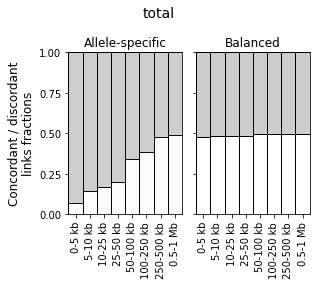

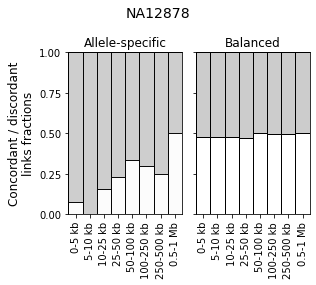

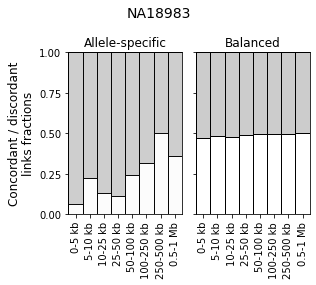

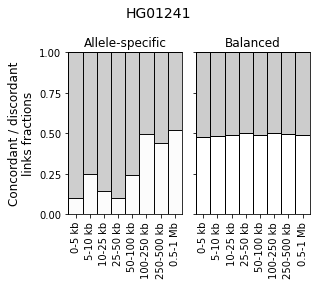

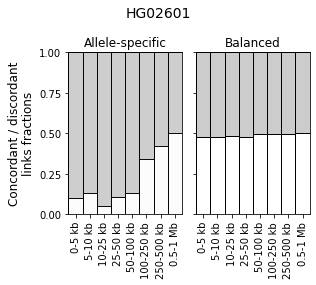

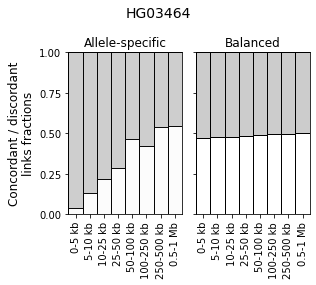

In [36]:
for sample in ['total', 'NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464']:
    plt.figure(figsize = (4.5, 4))
    plt.suptitle(sample, fontsize = 14)
    
    plt.subplot(121)
    plt.title('Allele-specific', fontsize = 12)
    for i, conc, disc in zip(np.arange(len(concordant_discordant_counts)), concordant_discordant_counts[sample + '_as_concordant'], concordant_discordant_counts[sample + '_as_discordant']):
        plt.bar([i, i], [1, 1-conc/(conc+disc)], color = ['#CCCCCC', 'w'], edgecolor = 'k', width = 1, alpha = 0.95)
    plt.xticks(np.arange(len(concordant_discordant_counts)), 
               ['0-5 kb', '5-10 kb', '10-25 kb', '25-50 kb', '50-100 kb', '100-250 kb', '250-500 kb', '0.5-1 Mb'], rotation = 90)
    plt.yticks([0, 0.25, 0.5, 0.75, 1])
    plt.xlim((-0.5, 7.5))
    plt.ylim((0, 1))
    plt.ylabel('Concordant / discordant\nlinks fractions', fontsize = 12)

    plt.subplot(122)
    plt.title('Balanced', fontsize = 12)
    for i, conc, disc in zip(np.arange(len(concordant_discordant_counts)), concordant_discordant_counts[sample + '_balanced_concordant'], concordant_discordant_counts[sample + '_balanced_discordant']):
        plt.bar([i, i], [1, 1-conc/(conc+disc)], color = ['#CCCCCC', 'w'], edgecolor = 'k', width = 1)
    plt.xticks(np.arange(len(concordant_discordant_counts)), 
               ['0-5 kb', '5-10 kb', '10-25 kb', '25-50 kb', '50-100 kb', '100-250 kb', '250-500 kb', '0.5-1 Mb'], rotation = 90)
    plt.yticks([0, 0.25, 0.5, 0.75, 1], [])
    plt.xlim((-0.5, 7.5))
    plt.ylim((0, 1))

    plt.tight_layout()
    plt.savefig(f'/DATA/users/m.magnitov/hap_phen/figures/links_same_tad_concordance_{sample}.pdf', bbox_inches = 'tight')
    plt.show()